In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error

# Загрузите изображение в оттенках серого sar_1_gray.jpg.


In [2]:
image = cv2.imread("images-20260917T190232Z-1-001/images/sar_1_gray.jpg", cv2.IMREAD_GRAYSCALE)

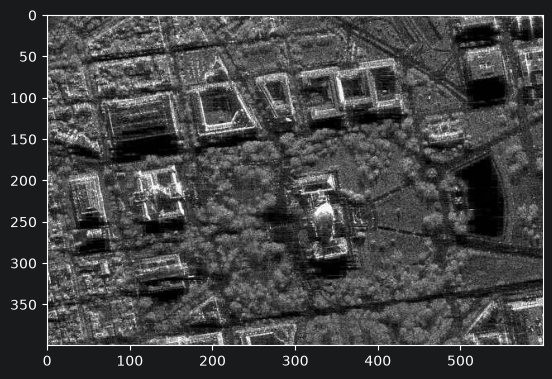

In [3]:
plt.imshow(image, cmap="gray")

# постройте гистограмму

In [4]:
histSize = 256
histRange = (0, 256)
accumulate = False

b_hist = cv2.calcHist([image], [0], None, [histSize], histRange, accumulate=accumulate)

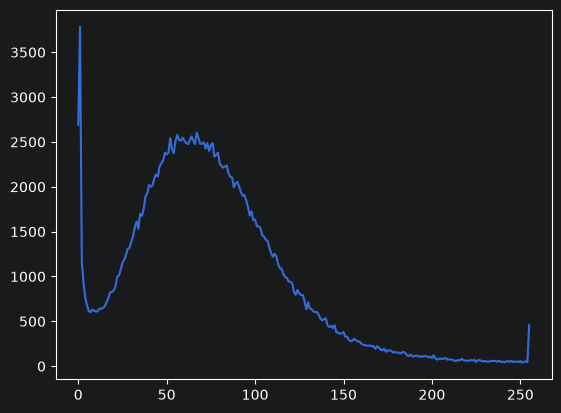

In [5]:
plt.plot(b_hist)

# Алгоритм гамма коррекции


In [6]:
def gamma_correction(image, gamma=1.0):
    norma = image / 255
    corrected_norma = np.power(norma, gamma)
    corrected_image = np.uint8(corrected_norma * 255)
    return corrected_image

# MSE, SSIM

In [7]:
img_light = gamma_correction(image, 0.5)
img_dark = gamma_correction(image, 2.0)

In [8]:
mse_light = mean_squared_error(image, img_light)
ssim_light = structural_similarity(image, img_light, full=True)
print(f'MSE = {mse_light}, SSIM = {ssim_light}')

MSE = 3250.429145833333, SSIM = (np.float64(0.7875008686792752), array([[0.76162437, 0.75437221, 0.74898764, ..., 0.89285407, 0.89164975,
        0.88871223],
       [0.75777427, 0.75328518, 0.75149089, ..., 0.89743597, 0.89998328,
        0.89368178],
       [0.74409353, 0.74325919, 0.74628402, ..., 0.89623098, 0.89945858,
        0.89356257],
       ...,
       [0.87606253, 0.87151073, 0.87311873, ..., 0.89227051, 0.89163086,
        0.88881457],
       [0.8815563 , 0.87787773, 0.87620566, ..., 0.89557841, 0.89650108,
        0.89408976],
       [0.88004882, 0.87814846, 0.87542753, ..., 0.89445155, 0.89627503,
        0.89797009]], shape=(400, 600)))


In [9]:
mse_dark = mean_squared_error(image, img_dark)
ssim_dark = structural_similarity(image, img_dark, full=True)
print(f'MSE = {mse_dark}, SSIM = {ssim_dark}')

MSE = 2383.7636375, SSIM = (np.float64(0.5270459922820343), array([[0.322083  , 0.31476143, 0.30789508, ..., 0.89562653, 0.89671921,
        0.89406274],
       [0.31718273, 0.31284003, 0.30918771, ..., 0.88685194, 0.89369903,
        0.88797668],
       [0.30019333, 0.29866566, 0.29952135, ..., 0.86810327, 0.87915878,
        0.87268584],
       ...,
       [0.63791092, 0.62365512, 0.64470356, ..., 0.86303963, 0.87638213,
        0.88371302],
       [0.65699526, 0.64035487, 0.65295874, ..., 0.83328617, 0.84858159,
        0.86499082],
       [0.66419898, 0.64924212, 0.64444195, ..., 0.805579  , 0.82058999,
        0.84577105]], shape=(400, 600)))


# сравнение изображеий(гамма коррекция)

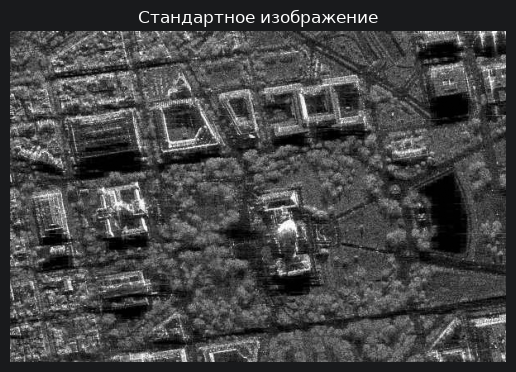

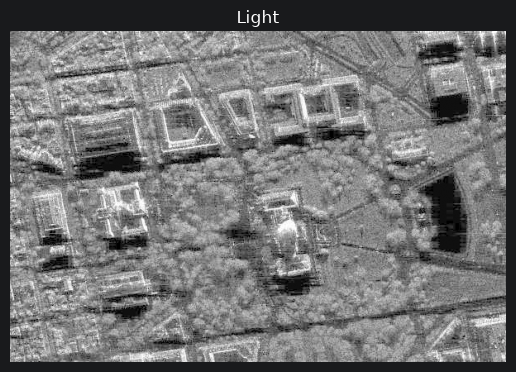

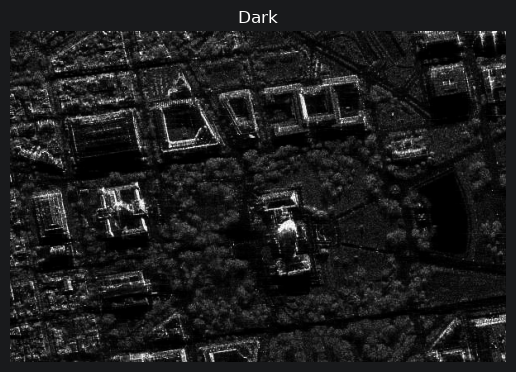

In [10]:
plt.imshow(image, cmap="gray")
plt.axis('off')
plt.title('Стандартное изображение')
plt.show()

plt.imshow(img_light, cmap="gray")
plt.axis('off')
plt.title('Light')
plt.show()

plt.imshow(img_dark, cmap="gray")
plt.axis('off')
plt.title('Dark')
plt.show()

# алгоритм статистической цветокоррекции

In [11]:
def statistical_color_correction(target, source):
    E_T = np.mean(target)
    D_T = np.std(target)
    E_S = np.mean(source)
    D_S = np.std(source)
    c = E_S + (target.astype(np.float64) - E_T) * (D_S / (D_T + 1e-8))
    c = np.clip(c, 0, 255).astype(np.uint8)
    return c

In [12]:
eq_gray = cv2.equalizeHist(image)
img_stat_corrected = statistical_color_correction(image, eq_gray)

(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

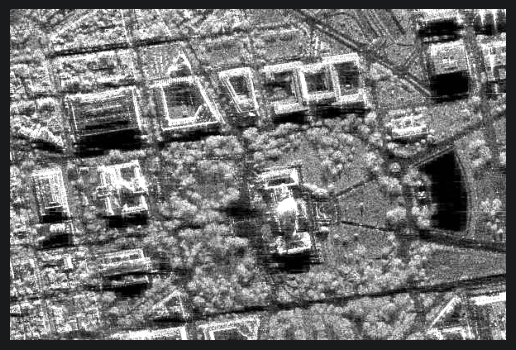

In [13]:
plt.imshow(img_stat_corrected, cmap="gray")
plt.axis('off')

# Пороговая фильтрация

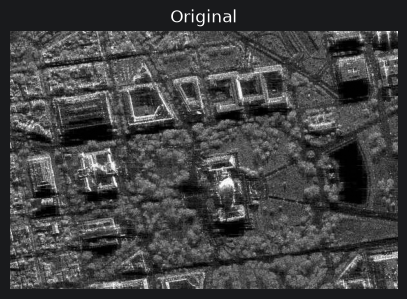

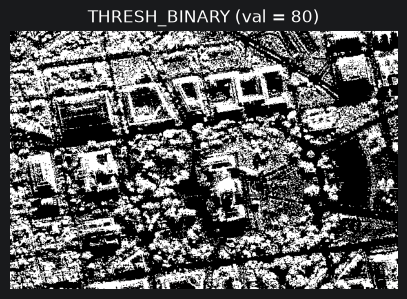

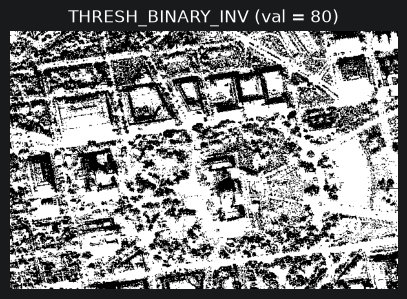

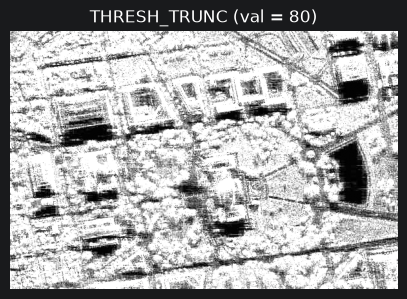

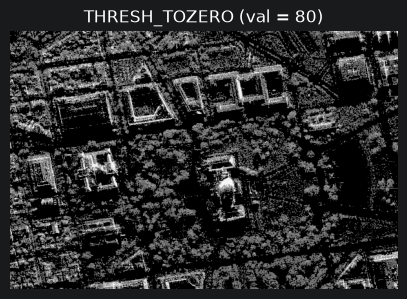

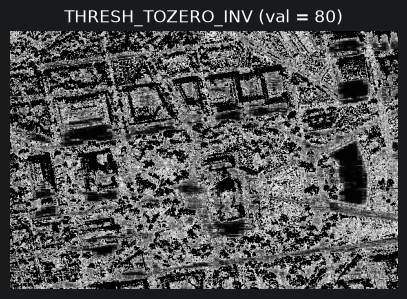

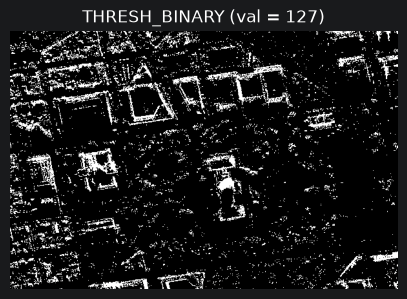

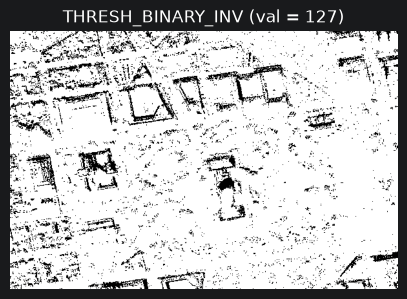

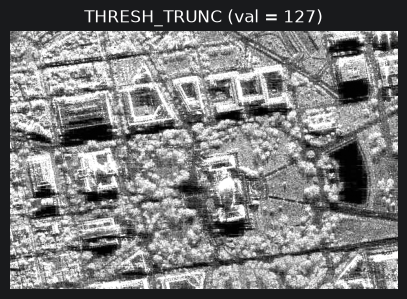

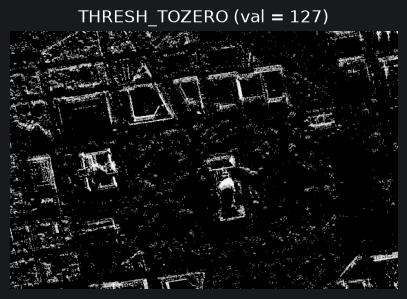

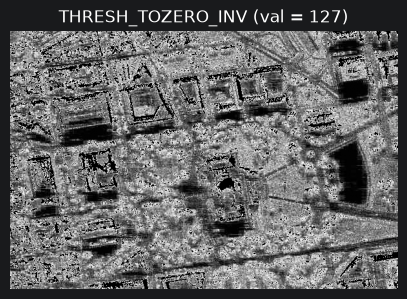

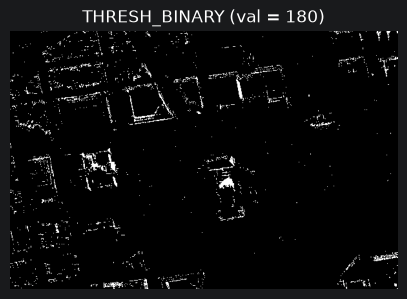

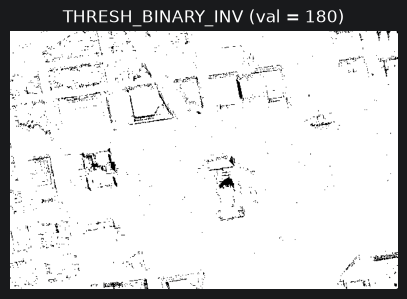

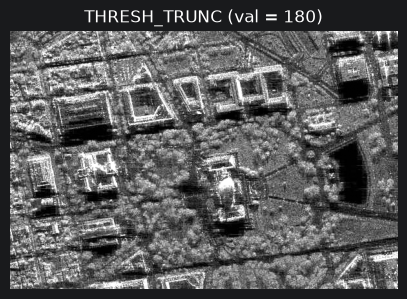

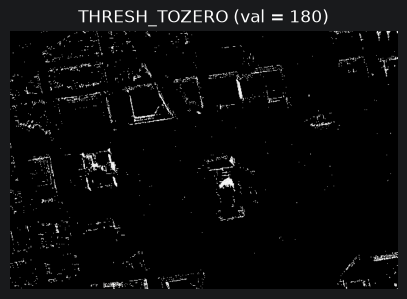

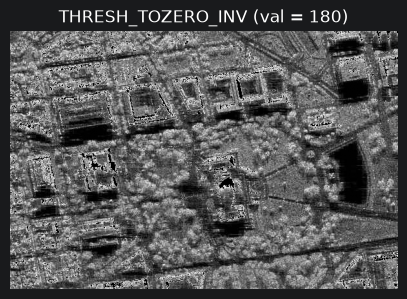

In [14]:
threshold_values = [80, 127, 180]
max_val = 255
plt.figure(figsize=(5, 5))
plt.imshow(image, cmap='gray')
plt.title('Original')
plt.axis('off')
plt.show()
for thresh_val in threshold_values:
    _, th_binary     = cv2.threshold(image, thresh_val, max_val, cv2.THRESH_BINARY)
    _, th_binary_inv = cv2.threshold(image, thresh_val, max_val, cv2.THRESH_BINARY_INV)
    _, th_trunc      = cv2.threshold(image, thresh_val, max_val, cv2.THRESH_TRUNC)
    _, th_tozero     = cv2.threshold(image, thresh_val, max_val, cv2.THRESH_TOZERO)
    _, th_tozero_inv = cv2.threshold(image, thresh_val, max_val, cv2.THRESH_TOZERO_INV)
    images = [th_binary, th_binary_inv, th_trunc, th_tozero, th_tozero_inv]
    titles = [f'THRESH_BINARY (val = {thresh_val})', f'THRESH_BINARY_INV (val = {thresh_val})', f'THRESH_TRUNC (val = {thresh_val})', f'THRESH_TOZERO (val = {thresh_val})', f'THRESH_TOZERO_INV (val = {thresh_val})']
    for img, title in zip(images, titles) :
        plt.figure(figsize=(5, 5))
        plt.imshow(img, cmap='gray')
        plt.title(title)
        plt.axis('off')
        plt.show()
